# Software Development and Python Basics

In this notebook, basics for developing a project in Python are shown.
Since you have already had courses with Python, most of this should not be new, rather important parts should be repeated.
If important topics are still missing for you, they can be added.

In [2]:
import datetime
import random
from pathlib import Path

import pandas as pd

## Organization of a Python Project

A brief overview of how you can organize your code, from first steps and simple programs to components that can be reused well.

### Notebook

As a first method, notebooks are very suitable for quickly trying out things and displaying results immediately.
If you keep cleaning up and also use features like Markdown headings and text,
they are also very good for illustrating the individual steps and testing new things.
However, since changes are done often in different places, these can also become quite quickly very confusing.

In [4]:
# Tip to automatically reload your own functions
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Scripts

If the code is copied into a Python file as defined in the notebook, so that it is executed from top to bottom,
it is called script. In most cases, you will execute the main steps of your project
in a script. Ideally, the important components are only called here,
and are structured and implemented in other files.

### Functions

As soon as the desired approach has been tested in the notebook, it makes sense to divide it into
individual functions. These have a clearly defined task, defined
input and output parameters and can thus be reused.

Recommendation: Before putting code into functions, think about what input and
output parameters are expected. This is best done by first writing the signature of the function
including docstring, and then transferring the functionality from the notebook, often with
some generalizations.



In [5]:
# Example of a Function stub, to define functionality, in and output parameters before the implementation
def load_profile_for_day(  # Descriptive Name
    day: datetime.date,
    profile_df: pd.DataFrame,
    dynamize: bool = False,  # Parameters, with type hints to make explicit what we expect
) -> pd.Series:  # Return type
    # Docstring with one title line, optionally some more description, and a description of Arguments and what is returned
    """Get the 15 minute load profile for a single day.

    Args:
        day (datetime.date): Date for which to get the load profile.
        profile_df (pd.DataFrame): In the format as given by get_profile_from_file.
        dynamize (bool): Should dynamization by the 4th-grade polynomial dynamization
            function for day of year be applied. This should be only done for H0. Defaults to False.

    Returns:
        pd.Series: Series with Watt values every 15 minutes, and a pd.DatetimeIndex.
    """
    pass  # Implementation follows in second step.

This approach was used for writing the function to load standard load profiles. In the notebook *11_load_profiles.ipynb* the logic is implemented in individual steps, then a function was created and finally
copied into a separate file *src/load_profiles.py*. From there, it can now be imported.

In [6]:
from src.load_profiles import get_load_profile

In [7]:
lastprofile_file = Path(".") / "data" / "representative_profiles_vdew.xls"
assert (
    lastprofile_file.is_file()
), f"Did not find file with representative load profiles at {lastprofile_file}"

In [8]:
h0profile = get_load_profile(
    lastprofile_file,
    from_=datetime.date(2015, 1, 1),
    to=datetime.date(2015, 12, 31),
    type="H0",
)

In [9]:
h0profile.head()

2015-01-01 00:15:00    108.677635
2015-01-01 00:30:00    100.728643
2015-01-01 00:45:00     93.152259
2015-01-01 01:00:00     85.824281
2015-01-01 01:15:00     78.744710
dtype: float64

### Classes

Object-oriented programming is strongly based on classes. Especially useful when objects
should be created that also store their own state.
It is best to create the class in its own file, here is a short example as a reminder.

In [10]:
# Class Names by convention in CamelCase
# Inheriting from default class object
class Wuerfel(object):
    # properties can be defined statically here
    seiten = [1, 2, 3, 4, 5, 6]

    # __init__ method is called when the class is instantiated
    # Usually used to define properties dynamically
    # Every method has self as it's first argument, this is used to access all class properties and methods
    def __init__(self, init_seite_oben: int = None):
        if init_seite_oben is None:
            self.seite_oben = random.choice(self.seiten)
        else:
            self.seite_oben = init_seite_oben

    # methods, self and possibly more arguments, optional return
    def wurf(self):
        self.seite_oben = random.choice(self.seiten)

    def setzen(self, seite_oben: int):
        self.seite_oben = seite_oben

    def check_seite_oben(self) -> bool:
        if self.seite_oben in self.seiten:
            return True
        else:
            return False

In [11]:
# Instantiate 1
d1 = Wuerfel(1)
d1.seite_oben

1

In [12]:
d1.wurf()
d1.seite_oben

2

In [13]:
# Can create multiple instances of the class, they are independent of each other
d2 = Wuerfel()
d2.seite_oben

5

In [14]:
# d1 is independent
d1.seite_oben

2

In [15]:
print(d2.check_seite_oben())
d2.setzen(7)
print(d2.check_seite_oben())

True
False


In [16]:
# Inspect class instance
dir(d2)
# __name__ methods are thunder methods that are defined by object. They are used for various operations
# Sometimes you want to redefine them, so you get special behaviour.
# _name methods and properties are usually private, so not intended to be used
# all our defined properties and methods are in the end

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'check_seite_oben',
 'seite_oben',
 'seiten',
 'setzen',
 'wurf']

In [17]:
# Overwrite the str method, that defines what happens when the class is printed / converted to string
print(d2)

In [18]:
def wuerfel_str(self):
    return str(self.seite_oben)


# Adding methods outside of the class definition is not good practice
Wuerfel.__str__ = wuerfel_str

In [19]:
print(d2)

7


## Timeseries

We work with time series, discretization in intervals, e.g. 15-minute values.

Python tool: pandas DataFrame (or Series) with DateTimeIndex.

### Data import

Data generated in notebooks 10 and 11 is loaded in the next step.
If this code does not work, run these two notebooks first.

In [20]:
pv = pd.read_csv("outputs/pv_example.csv")
pv.head()

,time(UTC),0
0,2015-01-01 00:00:00,-0.1
1,2015-01-01 01:00:00,-0.1
2,2015-01-01 02:00:00,-0.1
3,2015-01-01 03:00:00,-0.1
4,2015-01-01 04:00:00,-0.1


In [21]:
# May also directly read in index
g0 = pd.read_csv("outputs/g0_2015.csv", index_col=0)
g0.head()

,0
2015-01-01 00:15:00,63.2
2015-01-01 00:30:00,61.0
2015-01-01 00:45:00,58.9
2015-01-01 01:00:00,57.0
2015-01-01 01:15:00,55.3


### DatetimeIndex und Zeitzonen

A big advantage of Pandas is that more complex objects can form the index, such as datetimes.
These can be used to easily select different time periods. Plots have a time axis by default.
Switching between different intervals or making operations on intervals is implemented in the library .
First, a few examples with the load data from g0.

Especially when data from different sources is used, it is important that the times/timestamps match.
However, due to time zones, sommer/winter time, and different date formats, errors can easily occur.
These topics are  explained in few code examples in the next cells.

In [24]:
# Check if index is already DatetimeIndex
type(g0.index)

pandas.core.indexes.base.Index

In [26]:
# This does not work without a datetimeindex
g0.index.month
g0.loc["2015-05-01"]

AttributeError: 'Index' object has no attribute 'month'

In [27]:
# This works in many cases, for non-standard formats see further below
g0.index = pd.to_datetime(g0.index)
type(g0.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [28]:
# Now this works
g0.index.month.unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32')

In [29]:
# And this
g0.loc["2015-01-01 07:00":"2015-01-01 10:00"]

,0
2015-01-01 07:00:00,51.4
2015-01-01 07:15:00,51.8
2015-01-01 07:30:00,51.7
2015-01-01 07:45:00,51.2
2015-01-01 08:00:00,50.5
2015-01-01 08:15:00,49.6
2015-01-01 08:30:00,49.0
2015-01-01 08:45:00,48.8
2015-01-01 09:00:00,49.5
2015-01-01 09:15:00,51.3


<Axes: >

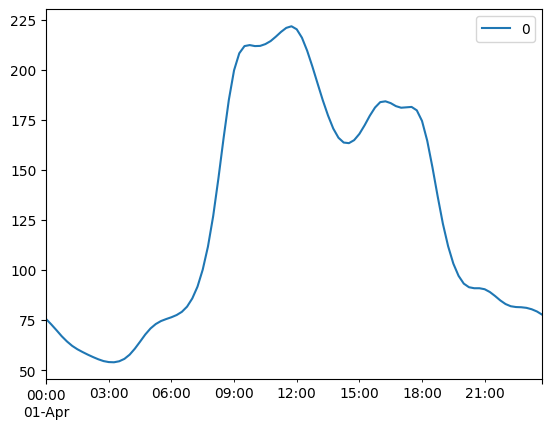

In [30]:
# And plotting with date axis
g0.loc["2015-04-01"].plot()
# TODO: Probably still an error in the data here, only one day with 'weekend' profile...

In [31]:
# As the pv data is hourly, let's resample our demand data to hours too
g0.sum() / 4.0  # This should give 1000 kWh -> g0 is in W

0    1102328.95
dtype: float64

In [32]:
# We resample by the mean as we have power units (would sum for energy)
g0_hourly = g0.resample("h").mean()

In [33]:
# And now calculate Energy consumption by month
# Check https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects for the offset strings
...

Ellipsis

In [34]:
# Check different datetime strings
print(pv.dtypes)
# This works again, and also is in UTC (nice!)
pd.to_datetime(pv["time(UTC)"])

time(UTC)     object
0            float64
dtype: object


0      2015-01-01 00:00:00
1      2015-01-01 01:00:00
2      2015-01-01 02:00:00
3      2015-01-01 03:00:00
4      2015-01-01 04:00:00
               ...        
8755   2015-12-31 19:00:00
8756   2015-12-31 20:00:00
8757   2015-12-31 21:00:00
8758   2015-12-31 22:00:00
8759   2015-12-31 23:00:00
Name: time(UTC), Length: 8760, dtype: datetime64[ns]

In [35]:
# But let's suppose a different format
pv["time2"] = pd.to_datetime(pv["time(UTC)"]).dt.strftime("%d.%m.%y %H:%M")
pv["time2"].head()

0    01.01.15 00:00
1    01.01.15 01:00
2    01.01.15 02:00
3    01.01.15 03:00
4    01.01.15 04:00
Name: time2, dtype: object

In [36]:
# As the warning states, this may not always work. In this case it mixed up month and day.
pd.to_datetime(pv["time2"][23:26])

C:\Users\z004uh1h\AppData\Local\Temp\ipykernel_36552\3576777588.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(pv["time2"][23:26])


23   2015-01-01 23:00:00
24   2015-02-01 00:00:00
25   2015-02-01 01:00:00
Name: time2, dtype: datetime64[ns]

In [37]:
# So better to explicitely specify the format
# Format according to the C standard formats: https://docs.python.org/3/library/datetime.html#strftime-and-strptime-format-codes
pd.to_datetime(pv["time2"][23:26], format="%d.%m.%y %H:%M")

23   2015-01-01 23:00:00
24   2015-01-02 00:00:00
25   2015-01-02 01:00:00
Name: time2, dtype: datetime64[ns]

In [38]:
# Even better to always use ISO 8601 format with time zone information
pv.index = pd.to_datetime(pv["time(UTC)"])
pv = pv.tz_localize("UTC")
pv.head()

,time(UTC),0,time2
time(UTC),,,
2015-01-01 00:00:00+00:00,2015-01-01 00:00:00,-0.1,01.01.15 00:00
2015-01-01 01:00:00+00:00,2015-01-01 01:00:00,-0.1,01.01.15 01:00
2015-01-01 02:00:00+00:00,2015-01-01 02:00:00,-0.1,01.01.15 02:00
2015-01-01 03:00:00+00:00,2015-01-01 03:00:00,-0.1,01.01.15 03:00
2015-01-01 04:00:00+00:00,2015-01-01 04:00:00,-0.1,01.01.15 04:00


In [39]:
# We also have to use load profiles with timezone now! Should be changed in functionality, as this is in local time
g0.tz_localize("Europe/Berlin")

NonExistentTimeError: 2015-03-29 02:00:00

In [40]:
g0 = g0.tz_localize("Europe/Berlin", ambiguous="NaT", nonexistent="shift_forward")
g0.head()

,0
2015-01-01 00:15:00+01:00,63.2
2015-01-01 00:30:00+01:00,61.0
2015-01-01 00:45:00+01:00,58.9
2015-01-01 01:00:00+01:00,57.0
2015-01-01 01:15:00+01:00,55.3


In [41]:
# Handling missing values. After this suboptimal transformation, we have missing values now
print(g0.index.isna().sum())
g0h = g0.resample("H").mean()
g0h.isna().sum()

4


C:\Users\z004uh1h\AppData\Local\Temp\ipykernel_36552\937635530.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g0h = g0.resample("H").mean()


0    2
dtype: int64

In [42]:
g0h = g0h.ffill()  # Here we use Forward fill, may use bfill or value
# g0h = g0h.fillna(0)
g0h.isna().sum()

0    0
dtype: int64

In [43]:
# Make one DF with pv and g0 data
df = pd.DataFrame({"PV": pv["0"], "G0": g0h.squeeze()})
df.head()

,PV,G0
2014-12-31 23:00:00+00:00,NaN,61.033333
2015-01-01 00:00:00+00:00,-0.1,54.525000
2015-01-01 01:00:00+00:00,-0.1,47.825000
2015-01-01 02:00:00+00:00,-0.1,42.900000
2015-01-01 03:00:00+00:00,-0.1,41.875000


###  Graphic Libraries for working with Pandas

* mito / mitosheet
* bamboolib
* pandasgui

I have tested mitosheet and believe that you can use it to start your data workflow quite well.
One thing that is not so well supported are indices.



## Visualization

Usefuel libraries for visualization of data are:
* matplotlib
* seaborn
* plotly

## Data

* [APCS](https://www.apcs.at/de/clearing/technisches-clearing/lastprofile)
* [OPSD](https://open-power-system-data.org/)
* https://solar.htw-berlin.de/elektrische-lastprofile-fuer-wohngebaeude/
* https://www.renewables.ninja/
* https://joint-research-centre.ec.europa.eu/photovoltaic-geographical-information-system-pvgis_en
* https://simbench.de/de/datensaetze/


## Libraries

### Connection to Vienna Net Smart Meter Data

Vienna Net Smart Meter Portal https://smartmeter-web.wienernetze.at/#/welcome.

Git Repository for retrieval via API: https://github.com/platysma/vienna-smartmeter

## Best Practices

* Docstrings
* Type Hints
* Start with Notebook, move important pieces to .py file
* black autoformatter
* Exception Handling
* autoreload

